In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision.models import inception_v3, mobilenet_v2
import torch.nn.functional as F
from torchvision.transforms import Resize

In [2]:
def adaptive_mix(x_real, x_fake, alpha=1.0):
    lambda_val = torch.distributions.Beta(alpha, alpha).sample().to(x_real.device)
    mixed_x = lambda_val * x_real + (1 - lambda_val) * x_fake
    return mixed_x


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim, img_channels):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_channels * 32 * 32),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 3, 32, 32)

class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 32 * 32, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def get_dataloader(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [4]:
def inception_score(images, device, num_splits=10):
    model = mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1").to(device)
    model.classifier = nn.Identity()
    model.eval()

    resize = Resize((64, 64))

    scores = []
    with torch.no_grad():
        for i in range(num_splits):
            batch = images[i::num_splits].to(device)
            batch = resize(batch)
            preds = model(batch)
            preds = F.softmax(preds, dim=1).cpu().numpy()
            kl_div = preds * (np.log(preds) - np.log(np.expand_dims(preds.mean(axis=0), 0)))
            scores.append(np.exp(kl_div.sum(axis=1).mean()))

    return np.mean(scores), np.std(scores)

In [9]:
# Global list to store Inception Scores
is_list = []

def train_gan(epochs=50, batch_size=128, alpha=1.0, z_dim=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataloader = get_dataloader(batch_size)
    img_channels = 3

    generator = Generator(z_dim, img_channels).to(device)
    discriminator = Discriminator(img_channels).to(device)

    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    real_label, fake_label = 1, 0

    loss_g_list, loss_d_list = [], []

    for epoch in range(epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            z = torch.randn(batch_size, z_dim).to(device)
            fake_images = generator(z)

            mixed_images = adaptive_mix(real_images, fake_images, alpha)

            optimizer_d.zero_grad()
            real_output = discriminator(real_images)
            fake_output = discriminator(fake_images.detach())

            loss_d_real = criterion(real_output, torch.ones_like(real_output) * 0.9)
            loss_d_fake = criterion(fake_output, torch.zeros_like(fake_output))
            loss_d = (loss_d_real + loss_d_fake) / 2
            loss_d.backward()
            optimizer_d.step()

            optimizer_g.zero_grad()
            fake_output = discriminator(fake_images)
            loss_g = criterion(fake_output, torch.ones_like(fake_output) * 0.9)
            loss_g.backward()
            optimizer_g.step()

        is_mean, is_std = inception_score(fake_images, device)
        is_list.append(is_mean)  # Append to the global is_list
        loss_g_list.append(loss_g.item())
        loss_d_list.append(loss_d.item())
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f} | IS: {is_mean:.2f} ± {is_std:.2f}")

    return generator, device # Return generator and device


100%|██████████| 170M/170M [00:05<00:00, 30.5MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 89.5MB/s]


Epoch [1/50] | Loss D: 0.2100 | Loss G: 4.6410 | IS: 1.00 ± 0.00
Epoch [2/50] | Loss D: 0.3790 | Loss G: 11.2865 | IS: 1.00 ± 0.00
Epoch [3/50] | Loss D: 0.2308 | Loss G: 6.9874 | IS: 1.00 ± 0.00
Epoch [4/50] | Loss D: 0.2337 | Loss G: 4.1731 | IS: 1.00 ± 0.00
Epoch [5/50] | Loss D: 0.2373 | Loss G: 2.7838 | IS: 1.00 ± 0.00
Epoch [6/50] | Loss D: 0.2272 | Loss G: 4.0224 | IS: 1.00 ± 0.00
Epoch [7/50] | Loss D: 0.2617 | Loss G: 5.4150 | IS: 1.00 ± 0.00
Epoch [8/50] | Loss D: 0.3158 | Loss G: 3.4938 | IS: 1.00 ± 0.00
Epoch [9/50] | Loss D: 0.2880 | Loss G: 3.4511 | IS: 1.00 ± 0.00
Epoch [10/50] | Loss D: 0.2333 | Loss G: 4.0536 | IS: 1.01 ± 0.00
Epoch [11/50] | Loss D: 0.3424 | Loss G: 2.9681 | IS: 1.00 ± 0.00
Epoch [12/50] | Loss D: 0.3034 | Loss G: 3.3431 | IS: 1.01 ± 0.00
Epoch [13/50] | Loss D: 0.3483 | Loss G: 2.8187 | IS: 1.01 ± 0.00
Epoch [14/50] | Loss D: 0.3945 | Loss G: 2.3591 | IS: 1.01 ± 0.00
Epoch [15/50] | Loss D: 0.4637 | Loss G: 2.1145 | IS: 1.01 ± 0.00
Epoch [16/50] | Lo

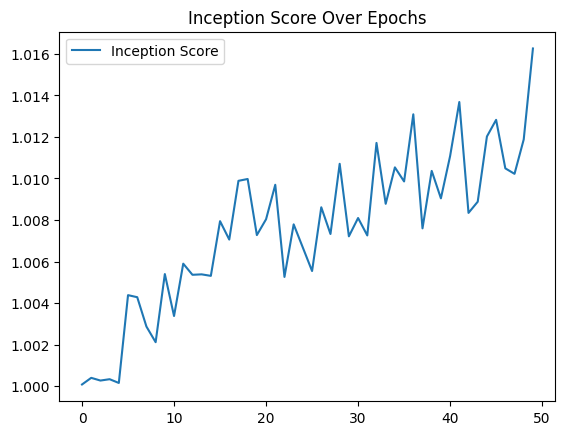

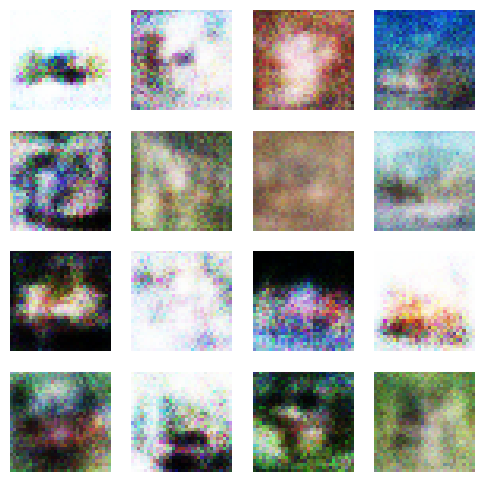

In [10]:
# Main execution block
if __name__ == "__main__":
    generator, device = train_gan(epochs=50) # Get generator and device from train_gan

    # Plotting the Inception Score
    plt.plot(is_list, label='Inception Score')
    plt.legend()
    plt.title('Inception Score Over Epochs')
    plt.show()

    # Generating and displaying images
    z_dim = 100 # Define z_dim here
    with torch.no_grad():
        z = torch.randn(16, z_dim).to(device)
        gen_images = generator(z).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        img = gen_images[i].permute(1, 2, 0).numpy()
        ax.imshow((img + 1) / 2)
        ax.axis('off')
    plt.show()